# Kaggle Titanic Challenge
****

In [15]:
# https://www.kaggle.com/datasets/yasserh/titanic-dataset?select=Titanic-Dataset.csv

!curl -L -o ~/Downloads/archive.zip https://www.kaggle.com/api/v1/datasets/download/yasserh/titanic-dataset | unzip ~/Downloads/archive.zip

Archive:  /home/paiflare/Downloads/archive.zip
replace Titanic-Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 22564  100 22564    0     0  17970      0  0:00:01  0:00:01 --:--:-- 92097
 NULL
(EOF or read error, treating as "[N]one" ...)


In [16]:
import pandas as pd

In [17]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Variable Notes
   - **PassengerId** Unique ID of the passenger

   - **Survived** Survived (1) or died (0)

   - **Pclass** Passenger's class (1st, 2nd, or 3rd)

   - **Name** Passenger's name

   - **Sex** Passenger's sex

   - **Age** Passenger's age

   - **SibSp** Number of siblings/spouses aboard the Titanic

   - **Parch** Number of parents/children aboard the Titanic

   - **Ticket** Ticket number

   - **Fare** Fare paid for ticket

   - **Cabin** Cabin number

   - **Embarked** Where the passenger got on the ship (C - Cherbourg, S - Southampton, Q = Queenstown)

In [1]:
# Выясниете какой размер таблицы

# <YOUR CODE>

In [50]:
#answer
df.shape

(891, 16)

In [2]:
# Выясните какие столбцы имеют пропущенные значения и сколько их в этих столбцах

# <YOUR CODE>

In [ ]:
#answer
df.info()
df.isna().sum()
# df.isna().sum().sum()

# 1. Who were the passengers on the titanic?

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="ticks")
plt.style.use("fivethirtyeight")

In [3]:
# Посчитайте сколько мужчин и женщин было на корабле

# <YOUR CODE>

male: 577
female: 314


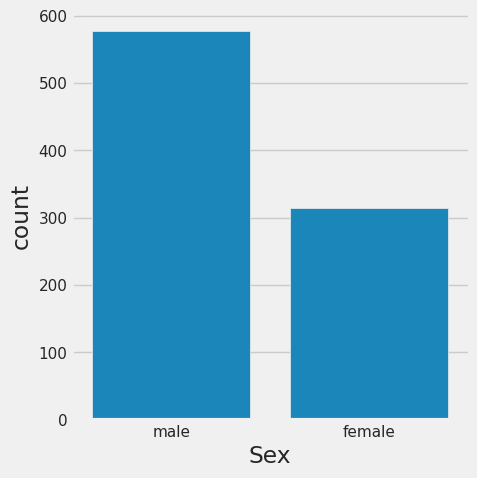

In [24]:
#answer
male_cnt = (df["Sex"] == "male").sum()
female_cnt = (df["Sex"] == "female").sum()

print(f"male: {male_cnt}")
print(f"female: {female_cnt}")

sns.catplot(x='Sex', data=df, kind='count')

In [4]:
# Посчитайте сколько на корабле из пассажиров 3-его класса было мужчин и женщин

# <YOUR CODE>

In [ ]:
# answer
male3_cnt = ((df["Sex"] == "male") & (df["Pclass"] == 3)).sum()
female3_cnt = ((df["Sex"] == "female") & (df["Pclass"] == 3)).sum()

print(f"male3: {male3_cnt}")
print(f"female3: {female3_cnt}")

sns.catplot(x='Pclass', data=df, hue='Sex', kind='count')

In [5]:
# Создайте новую колонку "person", в которой будут значения из "sex" (т.е. "male" или "female"), но там, где возраст < 16, должно быть значение "child".
# Посчитайте сколько детей на корабле и какой средний возраст пассажиров.

# <YOUR CODE>

Distribution of person : male      537
female    271
Child      83
Name: Person, dtype: int64
Mean age : 29.69911764705882


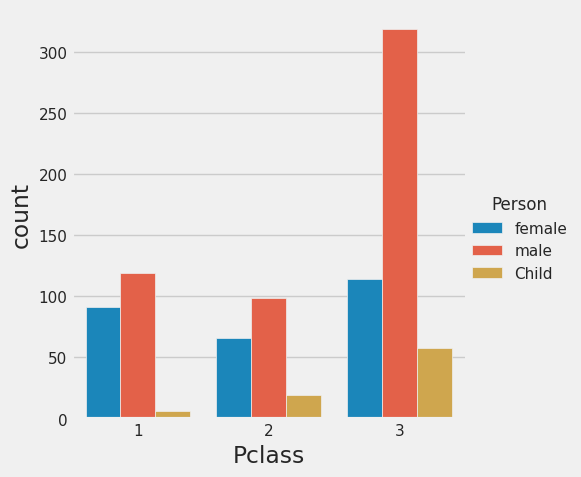

In [32]:
#answer
df['Person'] = df.Sex
df.loc[df['Age'] < 16, 'Person'] = 'Child'

print(f"Distribution of person : {df.Person.value_counts()}\n=================================")
print(f"Mean age : {df.Age.mean()}\n=================================")

sns.catplot(x='Pclass', data=df, hue='Person', kind='count')

<Axes: >

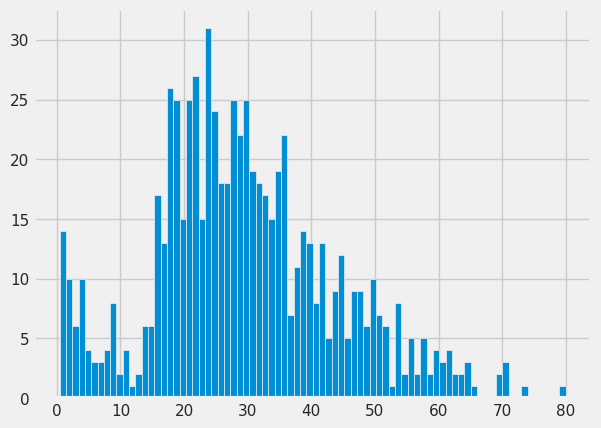

In [33]:
# visualizing age distribution
df["Age"].hist(bins=80)

# 2. What deck were the passengers on and how does that relate to their class?

In [34]:
# First we'll drop the NaN values and create a new object, deck
deck = df['Cabin'].dropna()
deck

1              C85
3             C123
6              E46
10              G6
11            C103
          ...     
871            D35
872    B51 B53 B55
879            C50
887            B42
889           C148
Name: Cabin, Length: 204, dtype: object

Notice we only need the first letter of the deck to classify its level (e.g. A, B, C, D, E, F, G)

In [6]:
# Посчитайте кол-во кают каждого класса (т.е. сколько кают класса "A", сколько кают класса "B"  и т.д.).
# Используйте для этого deck (pd.Series) (для того, чтобы не учитывать Null)

# <YOUR CODE>

In [ ]:
# answer
df["CabinLvl"] = deck.str[0]
cabin_df = df.groupby("CabinLvl")["Cabin"].count()
cabin_df.sort_values(inplace=True, ascending=False)

print(cabin_df)

sns.catplot(data=df, x="CabinLvl", kind='count', palette='winter_d');

# 3. Who was alone and who was with family?

In [46]:
# Let's start by adding a new column to define alone
# We'll add the parent/child column with the sibsp column

df['Alone'] = df.SibSp + df.Parch
df.Alone

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: Alone, Length: 891, dtype: int64

Now we know that if the Alone column is anything but 0, then the passenger had family aboard and wasn't alone. So let's change the column now so that if the value is greater than 0, we know the passenger was with his/her family, otherwise they were alone.

In [7]:
# Замениет значения в колонке "alone" на "with family" (там, где > 0) и "alone" (там, где == 0).
# Посчитайте сколько пассажиров были одни

# <YOUR CODE>

In [76]:
# answer
df.loc[df['Alone'] > 0, 'Alone'] = 'with family'
df.loc[df['Alone'] == 0, 'Alone'] = 'alone'

alone: 537
with family: 354


/tmp/ipykernel_28864/1296144478.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Alone', data=df, kind='count', palette='Blues',


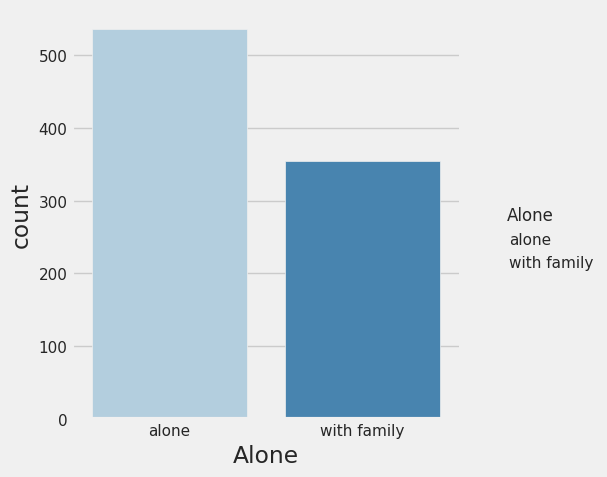

In [48]:
# Now let's get a simple visualization!

alone_cnt = (df['Alone'] == "alone").sum()
with_family_cnt = (df["Alone"] == "with family").sum()

print(f"alone: {alone_cnt}")
print(f"with family: {with_family_cnt}")

sns.catplot(x='Alone', data=df, kind='count', palette='Blues',
            order=['alone', 'with family'])